Esquema óptimo convergió en la iteración 12


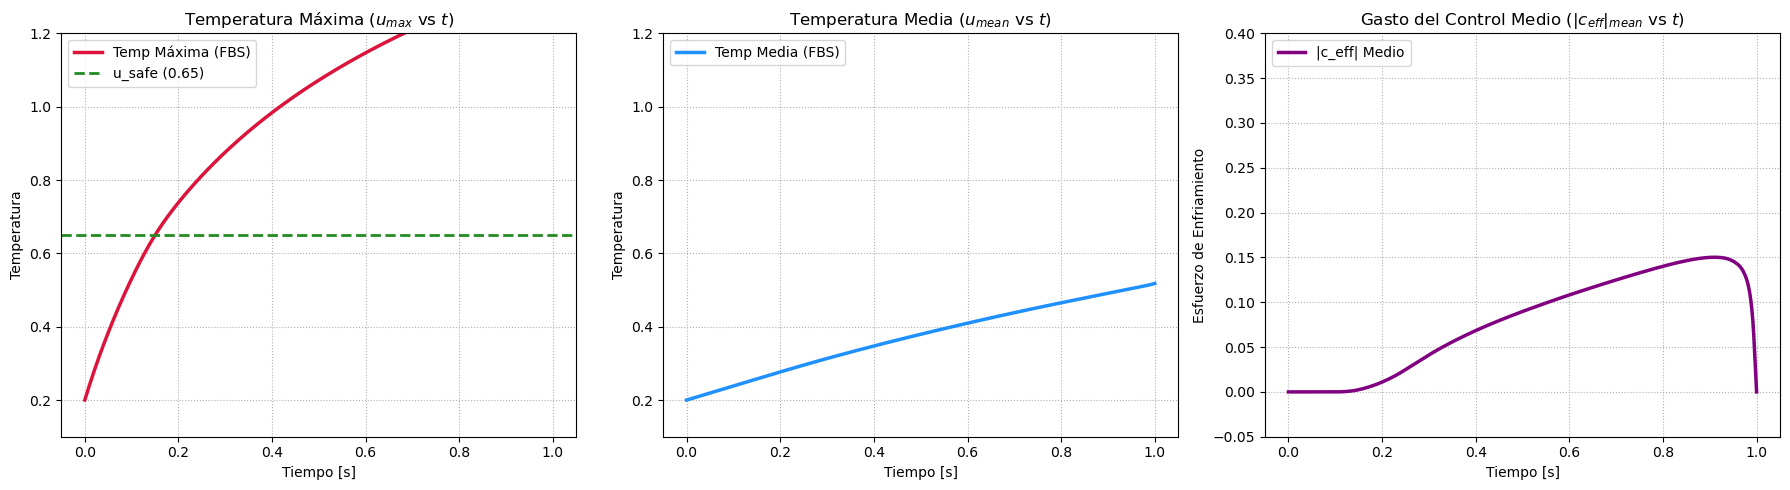

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def solve_thermal_fbs_pinn_plots():
    # --- Parámetros idénticos a la PINN ---
    nx, ny = 40, 40
    dt = 0.002
    total_time = 1.0
    nt = int(total_time / dt)  # 500 pasos de tiempo
    
    alpha = 0.02
    u_safe = 0.65
    k_gate = 30.0
    lambd = 0.01 
    dx = dy = 1.0 / (nx - 1)
    
    # Límite impuesto por el -C_MAX * abs(tanh(z))/2.0 (C_MAX = 1.5)
    c_limit = -0.75 
    
    # Malla espacial
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)
    
    # Fuentes de calor (Gaussianas del chip)
    g1 = 4.2 * np.exp(-((X-0.3)**2 + (Y-0.3)**2) / (2*0.08**2)) 
    g2 = 3.0 * np.exp(-((X-0.7)**2 + (Y-0.7)**2) / (2*0.08**2)) 
    g3 = 2.8 * np.exp(-((X-0.55)**2 + (Y-0.25)**2) / (2*0.08**2)) 
    Q = g1 + g2 + g3
    
    # Inicialización de matrices
    u = np.zeros((nt, nx, ny))
    p = np.zeros((nt, nx, ny))
    c_raw = np.zeros((nt, nx, ny)) 
    
    # Condición Inicial idéntica a tu PINN (u_init = 0.20)
    u[0] = 0.20 
    
    max_iter = 50
    tol = 1e-4

    for it in range(max_iter):
        u_old = u.copy()
        c_old = c_raw.copy()

        # --- 1. Forward Sweep (Estado u) ---
        for t in range(0, nt - 1):
            laplacian = (np.roll(u[t], -1, axis=0) + np.roll(u[t], 1, axis=0) +
                         np.roll(u[t], -1, axis=1) + np.roll(u[t], 1, axis=1) - 
                         4*u[t]) / dx**2
            
            gate = 1 / (1 + np.exp(-k_gate * (u[t] - u_safe)))
            c_eff = gate * c_raw[t]
            
            u[t+1] = u[t] + dt * (alpha * laplacian + Q + c_eff)
            
            # Condiciones de frontera Neumann (Aislado)
            u[t+1, 0, :] = u[t+1, 1, :]     
            u[t+1, -1, :] = u[t+1, -2, :]   
            u[t+1, :, 0] = u[t+1, :, 1]     
            u[t+1, :, -1] = u[t+1, :, -2]   

        # --- 2. Backward Sweep (Adjunto p) ---
        for t in range(nt - 1, 0, -1):
            laplacian_p = (np.roll(p[t], -1, axis=0) + np.roll(p[t], 1, axis=0) +
                           np.roll(p[t], -1, axis=1) + np.roll(p[t], 1, axis=1) - 
                           4*p[t]) / dx**2
            
            gate = 1 / (1 + np.exp(-k_gate * (u[t] - u_safe)))
            dgate_du = k_gate * gate * (1 - gate)
            dc_eff_du = c_raw[t] * dgate_du
            dloss_du = 2 * np.maximum(0, u[t] - u_safe)
            
            p[t-1] = p[t] + dt * (alpha * laplacian_p + p[t] * dc_eff_du + dloss_du)
            
            # BCs Neumann para p
            p[t-1, 0, :] = p[t-1, 1, :]
            p[t-1, -1, :] = p[t-1, -2, :]
            p[t-1, :, 0] = p[t-1, :, 1]
            p[t-1, :, -1] = p[t-1, :, -2]

        # --- 3. Actualización de Control Óptimo (Restricción PINN) ---
        gate_u = 1 / (1 + np.exp(-k_gate * (u - u_safe)))
        c_new = -(1/lambd) * p * gate_u
        c_new = np.clip(c_new, c_limit, 0.0) # Truncado estricto a [-0.75, 0.0]
        
        c_raw = 0.5 * c_new + 0.5 * c_old 

        # Criterio de parada
        error = np.linalg.norm(u - u_old) / (np.linalg.norm(u_old) + 1e-9)
        if error < tol:
            print(f"Esquema óptimo convergió en la iteración {it+1}")
            break

    # --- 4. Extracción de Métricas del Historial Temporal ---
    time_axis = np.linspace(0, total_time, nt)
    
    # Métrica A: Temperatura Máxima en cada instante t
    max_temps = np.max(u, axis=(1, 2))
    
    # Métrica B: Temperatura Media en toda la placa en cada instante t
    avg_temps = np.mean(u, axis=(1, 2))
    
    # Métrica C: Gasto del Control Medio (Magnitud promedio de enfriamiento efectiva en el chip)
    gate_f = 1 / (1 + np.exp(-k_gate * (u - u_safe)))
    c_eff_f = gate_f * c_raw
    mean_control_expenditure = np.mean(np.abs(c_eff_f), axis=(1, 2))

    # --- 5. Configuración de Gráficas Estilo PINN (1 Fila, 3 Columnas) ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfica 1: Temperatura Máxima
    ax1.plot(time_axis, max_temps, color='crimson', lw=2.5, label='Temp Máxima (FBS)')
    ax1.axhline(y=u_safe, color='forestgreen', ls='--', lw=2, label=f'u_safe ({u_safe})')
    ax1.set_title('Temperatura Máxima ($u_{max}$ vs $t$)')
    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('Temperatura')
    ax1.set_ylim(0.1, 1.2)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':')
    
    # Gráfica 2: Temperatura Media
    ax2.plot(time_axis, avg_temps, color='dodgerblue', lw=2.5, label='Temp Media (FBS)')
    ax2.set_title('Temperatura Media ($u_{mean}$ vs $t$)')
    ax2.set_xlabel('Tiempo [s]')
    ax2.set_ylabel('Temperatura')
    ax2.set_ylim(0.1, 1.2)
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle=':')
    
    # Gráfica 3: Gasto Medio de Control (Magnitud absoluta)
    ax3.plot(time_axis, mean_control_expenditure, color='purple', lw=2.5, label='|c_eff| Medio')
    ax3.set_title('Gasto del Control Medio ($|c_{eff}|_{mean}$ vs $t$)')
    ax3.set_xlabel('Tiempo [s]')
    ax3.set_ylabel('Esfuerzo de Enfriamiento')
    ax3.set_ylim(-0.05, 0.4) # Escala limpia para ver la evolución del promedio espacial
    ax3.legend(loc='upper left')
    ax3.grid(True, linestyle=':')
    
    plt.tight_layout()
    plt.show()
    
    return u, c_raw

# Ejecutar y graficar la validación exacta
u_res, c_res = solve_thermal_fbs_pinn_plots()